In [11]:
import pandas as pd               # read and handle dataset.
import numpy as np                # mathematical operations like vectors and matrices.
import matplotlib.pyplot as plt   # create charts.

data = pd.read_csv("student_performance_dataset.csv.xls")

data = data.select_dtypes(include=[np.number])  # selects only numeric columns (subject marks), ignoring names or IDs.

print(data.head()) 

   Math  Physics  Chemistry  English  Computer_Science  Total
0    78       41         44       91                87    341
1    91       91         58       59                75    374
2    68       70         62       76                60    336
3    54       79         56       95                84    368
4    82       54         65       55                57    313


In [12]:
X = data.values

v1 = X[0]                         # v1 represent one student score as a vector. it contains a marks of different subject. 
print("Student 1 Vector:", v1)

Student 1 Vector: [ 78  41  44  91  87 341]


In [13]:
# L1 Norm
l1 = np.linalg.norm(v1, 1)  # sum of absolute values (total score measure)

# L2 Norm
l2 = np.linalg.norm(v1)    # distance/magnitude of vector 
                           # Helps understand how large the vector (student performance) is
print("L1 Norm:", l1)
print("L2 Norm:", l2)

L1 Norm: 682.0
L2 Norm: 376.60589480251105


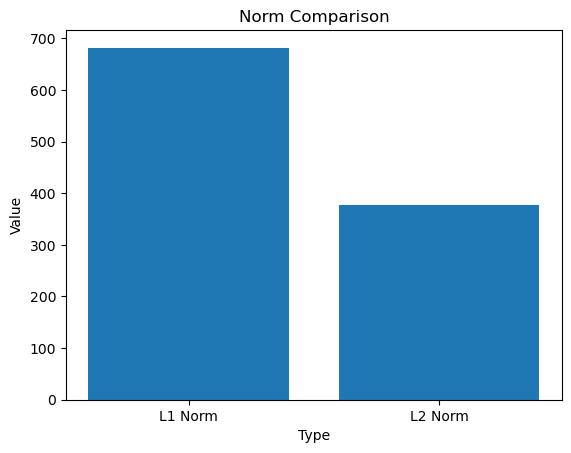

In [14]:
# plot bar chart for norm comparison.
 
plt.bar(["L1 Norm", "L2 Norm"], [l1, l2])
plt.title("Norm Comparison")
plt.xlabel("Type")
plt.ylabel("Value")
plt.show()

In [15]:
v2 = X[1]    # selects 2nd student’s marks as a vector

dot = np.dot(v1, v2)  # calculates dot product
angle = np.arccos(dot / (np.linalg.norm(v1) * np.linalg.norm(v2)))  # gives length (magnitude) of vector
      # np.arccos() → converts cosine value into angle

print("Dot Product:", dot)
print("Angle (radians):", angle)

Dot Product: 152809
Angle (radians): 0.15972065007626082


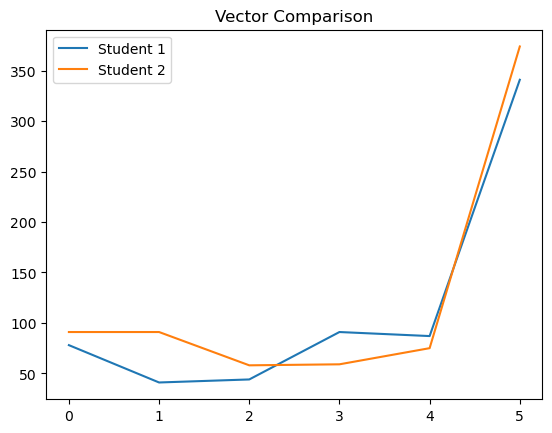

In [16]:
# plot line chart for vector comparison.

plt.plot(v1, label="Student 1")
plt.plot(v2, label="Student 2")
plt.legend()
plt.title("Vector Comparison")
plt.show()

In [17]:
cross = np.cross(v1[:3], v2[:3]) # gives a vector perpendicular to both vectors
                                 # takes first 3 subjects (because cross product works in 3D) 
print("Cross Product:", cross)

Cross Product: [-1626  -520  3367]


In [18]:
projection = (np.dot(v1, v2) / np.dot(v2, v2)) * v2   # to see how much v1 depends on v2
print("Projection:", projection)

Projection: [ 82.32658607  82.32658607  52.47189002  53.37657778  67.85158193
 338.35322187]


In [19]:
A = X                  # full dataset converted into matrix
print("Matrix:\n", A) 

Matrix:
 [[ 78  41  44  91  87 341]
 [ 91  91  58  59  75 374]
 [ 68  70  62  76  60 336]
 ...
 [ 63  85  40  93  54 335]
 [ 52  76  62  79  69 338]
 [ 99  98  35  88  70 390]]


In [20]:
print("Transpose:\n", A.T)   # Converts rows → columns

Transpose:
 [[ 78  91  68 ...  63  52  99]
 [ 41  91  70 ...  85  76  98]
 [ 44  58  62 ...  40  62  35]
 [ 91  59  76 ...  93  79  88]
 [ 87  75  60 ...  54  69  70]
 [341 374 336 ... 335 338 390]]


In [21]:
result = np.dot(A, A.T)             # Multiplies matrix with its transpose ,Creates similarity matrix ,Each value shows similarity between students
print("Multiplication:\n", result)

Multiplication:
 [[141832 152809 137614 ... 137555 138350 160368]
 [152809 168908 150802 ... 150615 151492 176259]
 [137614 150802 135640 ... 135582 136412 157690]
 ...
 [137555 150615 135582 ... 136584 136519 158581]
 [138350 151492 136412 ... 136519 137570 158368]
 [160368 176259 157690 ... 158581 158368 185374]]


In [22]:
small = A[:3, :3]            # Takes 3×3 sub-matrix
det = np.linalg.det(small)   # calculates determinant

print("Determinant:", det) 

Determinant: 61785.99999999991


In [23]:
cov = np.cov(A.T)                                 # calculates covariance matrix (relation between subjects)

eigenvalues, eigenvectors = np.linalg.eig(cov)    # np.linalg.eig() → finds: # Eigenvalues → importance of each feature
                                                                             # Eigenvectors → direction of data

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [ 1.78692628e+03 -1.11558372e-13  4.06904812e+02  3.24049028e+02
  2.75843006e+02  2.13797224e+02]
Eigenvectors:
 [[-0.18120803 -0.40824829  0.09977513 -0.6708804  -0.55586831  0.177403  ]
 [-0.25007355 -0.40824829  0.57009503  0.60992933 -0.19072755  0.19338412]
 [-0.2162499  -0.40824829 -0.80523684  0.33135571 -0.16689182  0.02265975]
 [-0.14620284 -0.40824829  0.0044869  -0.23214898  0.76257031  0.42015629]
 [-0.11376014 -0.40824829  0.12886435 -0.10123811  0.20561061 -0.86675317]
 [-0.90749447  0.40824829 -0.00201542 -0.06298244  0.05469324 -0.05315002]]


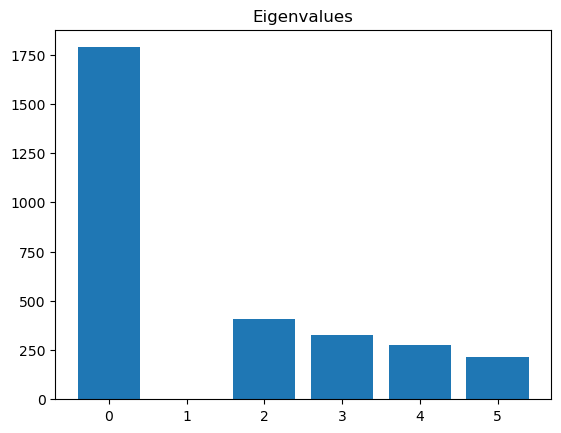

In [24]:
# plot bar chart for eigenvalues

plt.bar(range(len(eigenvalues)), eigenvalues)
plt.title("Eigenvalues")
plt.show()

In [25]:
U, S, V = np.linalg.svd(A)       # Breaks matrix into 3 parts: # U → left matrix
                                                               # S → singular values (importance)
                                                               # V → right matrix

print("Singular Values:", S)

Singular Values: [8.55410646e+03 4.50640992e+02 4.09375880e+02 3.75240918e+02
 3.30861004e+02 2.52379844e-13]


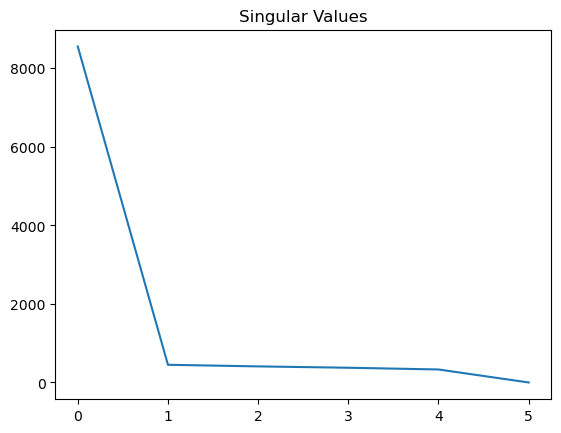

In [26]:
# plot line chart for sigular values

plt.plot(S)
plt.title("Singular Values")
plt.show()

In [27]:
from sklearn.decomposition import PCA  # PCA is used for dimensionality reduction
                                       # It reduces large data into smaller, meaningful form

pca = PCA(n_components=2)              # Reduce data into 2 dimensions (2 columns)
pca_result = pca.fit_transform(A)      # fit() Learns patterns from data and Finds important directions (principal components)
                                       # transform() Converts original data into new 2D data
print(pca_result)

[[-1.06434959e+01 -4.34697095e+00]
 [ 3.11470894e+01 -2.11190216e+01]
 [-1.11129838e+01 -1.85114861e+00]
 [ 2.18511868e+01 -1.35300751e+01]
 [-3.62124114e+01  8.72369387e+00]
 [ 2.13593945e+01 -2.39189816e+01]
 [-4.98742065e+01  1.85077016e+01]
 [ 4.67868565e+00  2.80288066e+01]
 [-6.18910319e+00  4.07509726e+00]
 [ 1.62647450e+01  2.43710145e+01]
 [-2.74790720e+01  1.26884042e+00]
 [ 2.20219914e+00  1.39081986e+01]
 [ 1.81445422e+01  1.67952394e+01]
 [-3.66559538e+01 -1.55904246e+01]
 [-1.40664826e+01 -3.88706914e+01]
 [ 8.06506884e+01 -1.85530086e+01]
 [ 6.66921449e+00 -3.27172805e+01]
 [-5.80290646e+01  5.65251984e+00]
 [ 4.33760355e+01 -2.71889182e+00]
 [ 4.33052292e+01 -6.02655491e-01]
 [ 6.80681080e+01  5.08906573e+00]
 [-5.00443405e+01 -2.45554347e+01]
 [ 7.98913524e+00 -8.17611530e+00]
 [-5.33125116e+01 -1.08080853e+01]
 [-2.87749626e+01 -3.76207855e+01]
 [ 7.55638739e+01 -2.43243884e+01]
 [-4.96013662e+01  2.47425388e+01]
 [ 7.30871535e+01  1.32370379e+01]
 [ 4.46083902e+01 -9

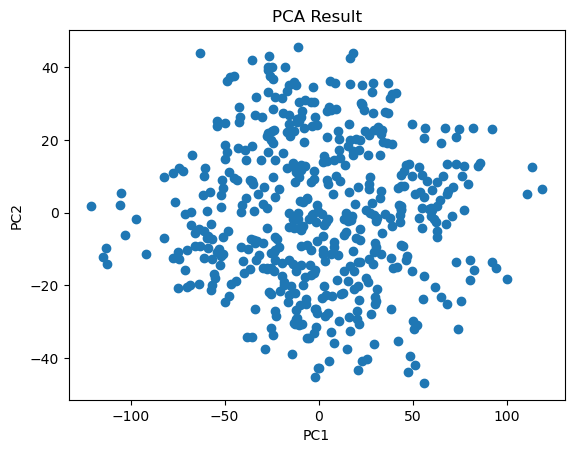

In [28]:
# plot a Scatter Plot chart for PCA result

plt.scatter(pca_result[:,0], pca_result[:,1])
plt.title("PCA Result")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [29]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Create labels
avg = np.mean(A, axis=1)    # Calculates average marks of each student
labels = ["Above" if x > np.mean(avg) else "Below" for x in avg]  # Classifies students:
                                                                      # Above average
                                                                      # Below average

lda = LinearDiscriminantAnalysis(n_components=1)
lda_result = lda.fit_transform(A, labels)   # Reduces data into 1 dimension
                                            # Separates students into groups

print(lda_result)

[[-2.03775631e-01]
 [ 1.26853003e+00]
 [-5.07915044e-01]
 [ 8.75980069e-01]
 [-1.46053926e+00]
 [ 8.14408667e-01]
 [-2.01748696e+00]
 [ 1.18473462e-01]
 [-1.81754838e-01]
 [ 6.85247595e-01]
 [-1.17978283e+00]
 [-2.61443158e-01]
 [ 4.94966459e-01]
 [-1.37279398e+00]
 [-5.34723690e-01]
 [ 3.25839403e+00]
 [ 2.02673748e-01]
 [-2.38448144e+00]
 [ 1.57158811e+00]
 [ 1.60259767e+00]
 [ 2.68134150e+00]
 [-2.07231030e+00]
 [ 2.51430307e-01]
 [-2.03801776e+00]
 [-1.07444491e+00]
 [ 3.10149998e+00]
 [-2.00022678e+00]
 [ 2.80145832e+00]
 [ 1.73190453e+00]
 [-2.73097056e+00]
 [-2.89275614e+00]
 [ 1.65724506e+00]
 [ 1.15372192e+00]
 [ 1.12556707e+00]
 [ 2.58943088e-02]
 [ 7.49038747e-01]
 [ 1.17886846e+00]
 [ 2.21121076e+00]
 [-7.97669581e-01]
 [ 5.67882323e-01]
 [ 9.35163418e-01]
 [-2.83590234e+00]
 [ 1.27571584e+00]
 [ 7.78166205e-01]
 [ 1.17192534e+00]
 [-2.34723930e+00]
 [ 1.61057176e+00]
 [ 1.03756815e+00]
 [-2.37015337e-01]
 [ 1.00692363e+00]
 [-2.42316558e+00]
 [ 7.47327446e-01]
 [-1.3389639

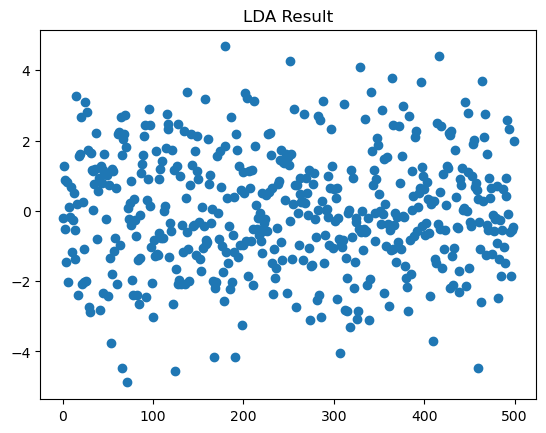

In [30]:
# plot a Scatter Plot chart for LDA result

plt.scatter(range(len(lda_result)), lda_result)
plt.title("LDA Result")
plt.show()

In [ ]:
🔹 THEORY
------------------------------------------------------------------------------------------------------------------------------------------------------

🔹Vector & Matrix Manipulation
=> Vectors represent student scores across subjects, while matrices organize multiple students’ data.
   Operations like addition and multiplication help analyze relationships between students and subjects.
   These concepts are widely used in data processing and machine learning.

🔹 Norms (L1 & L2)
=> Norms measure the magnitude of a vector.Norms measure the magnitude of a vector.
   L1 norm is the sum of absolute values, while L2 norm is the Euclidean distance.
   They help in understanding the size and importance of data.

🔹 Dot Product & Angle
=> The dot product measures similarity between two vectors.
   Using it, we can find the angle between vectors to understand how similar students’ performances are.
   Smaller angles indicate higher similarity.

🔹 Cross Product
=> The cross product is used in 3D vectors to find a perpendicular vector.
   It represents direction and orientation in space.
   In data science, it helps in geometric interpretations.

🔹 Projection
=> Projection shows how one vector relates to another.
   It helps in finding how much one student's performance aligns with another.
   This is useful in similarity analysis.

🔹 Matrix Operations
=> Matrix addition, multiplication, transpose, and determinant are key operations.
   They help transform and analyze structured data efficiently.
   These operations are fundamental in linear algebra.

🔹 Eigenvalues & Eigenvectors
=> Eigenvalues represent the importance of directions in data.
   Eigenvectors show those directions.
   They are used in PCA for dimensionality reduction.

🔹 SVD (Singular Value Decomposition)
=> SVD decomposes a matrix into three simpler matrices.
   It helps in reducing noise and extracting important features.
   Widely used in recommendation systems and data compression.

🔹 PCA (Principal Component Analysis)
=> PCA reduces high-dimensional data into fewer dimensions.
   It keeps the most important information while removing redundancy.
   Used for visualization and feature reduction.

🔹 LDA (Linear Discriminant Analysis)
=> LDA is used for classification.
   It separates data into different classes like above-average and below-average students.
   It maximizes class separation.